# Import necessary libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
# Display settings
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", "{:.2f}".format)
print("Libraries imported successfully")

Libraries imported successfully


In [3]:
import sys
sys.path.append("..")      
from src.load_data import load_raw_data

### Load data

In [6]:
# df = load_raw_data("data/raw/data.csv")
DATA_PATH = "../data/raw/data.csv"

In [7]:
df = pd.read_csv(
    DATA_PATH,
    encoding="ISO-8859-1")

In [8]:
print(f"   Rows:    {df.shape[0]:,}")
print(f"   Columns: {df.shape[1]}")

   Rows:    541,909
   Columns: 8


### BASIC LOOKUP

In [9]:
print("shape:", df.shape)

shape: (541909, 8)


In [10]:
print("\n Column names:", df.columns.tolist())


 Column names: ['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']


### FIRST LOOK

In [11]:
print("=" * 55)
print("COLUMN NAMES")
print("=" * 55)
print(df.columns.tolist())

print("\n" + "=" * 55)
print("DATA TYPES")
print("=" * 55)
print(df.dtypes)

print("\n" + "=" * 55)
print("SHAPE")
print("=" * 55)
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\n" + "=" * 55)
print("FIRST 5 ROWS")
print("=" * 55)
df.head()

COLUMN NAMES
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

DATA TYPES
InvoiceNo       object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
UnitPrice      float64
CustomerID     float64
Country         object
dtype: object

SHAPE
Rows:    541,909
Columns: 8

FIRST 5 ROWS


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.00,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.00,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.00,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.00,United Kingdom


###  Understand Each Column

In [12]:
for col in df.columns:
    print(f"\n{'─'*50}")
    print(f"Column: {col}")
    print(f"Type:   {df[col].dtype}")
    print(f"Nulls:  {df[col].isnull().sum():,} ({df[col].isnull().mean()*100:.1f}%)")
    print(f"Unique: {df[col].nunique():,}")


    if df[col].dtype == "object":
        # object dtype = string/text column
        print(f"Sample values: {df[col].dropna().unique()[:5].tolist()}")
    
    else:
        # Numeric column — show range
        print(f"Min: {df[col].min():.2f}  Max: {df[col].max():.2f}")
        print(f"Mean: {df[col].mean():.2f}  Median: {df[col].median():.2f}")


──────────────────────────────────────────────────
Column: InvoiceNo
Type:   object
Nulls:  0 (0.0%)
Unique: 25,900
Sample values: ['536365', '536366', '536367', '536368', '536369']

──────────────────────────────────────────────────
Column: StockCode
Type:   object
Nulls:  0 (0.0%)
Unique: 4,070
Sample values: ['85123A', '71053', '84406B', '84029G', '84029E']

──────────────────────────────────────────────────
Column: Description
Type:   object
Nulls:  1,454 (0.3%)
Unique: 4,223
Sample values: ['WHITE HANGING HEART T-LIGHT HOLDER', 'WHITE METAL LANTERN', 'CREAM CUPID HEARTS COAT HANGER', 'KNITTED UNION FLAG HOT WATER BOTTLE', 'RED WOOLLY HOTTIE WHITE HEART.']

──────────────────────────────────────────────────
Column: Quantity
Type:   int64
Nulls:  0 (0.0%)
Unique: 722
Min: -80995.00  Max: 80995.00
Mean: 9.55  Median: 3.00

──────────────────────────────────────────────────
Column: InvoiceDate
Type:   object
Nulls:  0 (0.0%)
Unique: 23,260
Sample values: ['12/1/2010 8:26', '12/1/2010

### Missing Value Analysis

MISSING VALUE REPORT
             missing_count  missing_percent
CustomerID          135080            24.93
Description           1454             0.27


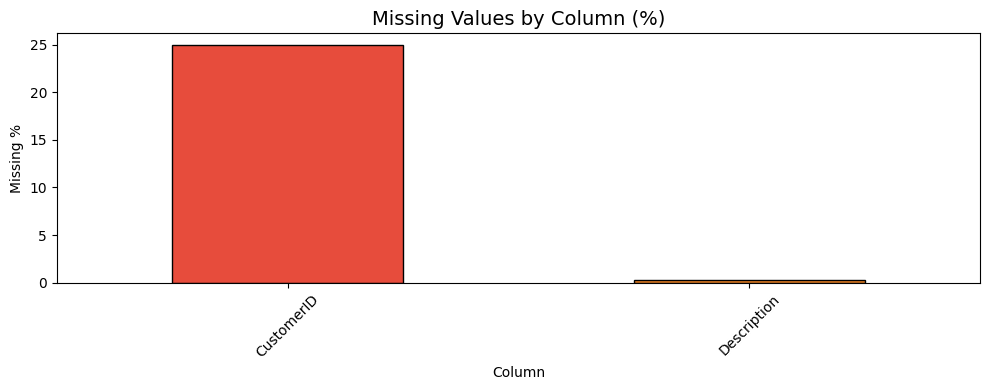

In [13]:
print("=" * 55)
print("MISSING VALUE REPORT")
print("=" * 55)

# Build a proper missing value summary
missing_report = pd.DataFrame({
    "missing_count": df.isnull().sum(),

    "missing_percent": (df.isnull().sum() / len(df) * 100).round(2)
 
})

# Only show columns that HAVE missing values
missing_report = missing_report[missing_report["missing_count"] > 0]
missing_report = missing_report.sort_values("missing_percent", ascending=False)


print(missing_report)

plt.figure(figsize=(10, 4))

missing_report["missing_percent"].plot(
    kind="bar",
    color=["#e74c3c", "#e67e22"],
    edgecolor="black"
)
plt.title("Missing Values by Column (%)", fontsize=14)
plt.xlabel("Column")
plt.ylabel("Missing %")
plt.xticks(rotation=45)
# rotate x labels so they don't overlap
plt.tight_layout()
plt.show()

### Understanding Missing CustomerID

In [14]:

missing_customers = df[df["CustomerID"].isnull()]


print(f"Rows with missing CustomerID: {len(missing_customers):,}")
print(f"\nWhat do these rows look like?")
print(missing_customers.head(10))

print(f"\nCountries with missing CustomerID:")
print(missing_customers["Country"].value_counts().head(10))


print(f"\nDate range of missing CustomerID rows:")
print(f"First: {missing_customers['InvoiceDate'].min()}")
print(f"Last:  {missing_customers['InvoiceDate'].max()}")


Rows with missing CustomerID: 135,080

What do these rows look like?
     InvoiceNo StockCode                          Description  Quantity  \
622     536414     22139                                  NaN        56   
1443    536544     21773      DECORATIVE ROSE BATHROOM BOTTLE         1   
1444    536544     21774      DECORATIVE CATS BATHROOM BOTTLE         2   
1445    536544     21786                   POLKADOT RAIN HAT          4   
1446    536544     21787                RAIN PONCHO RETROSPOT         2   
1447    536544     21790                   VINTAGE SNAP CARDS         9   
1448    536544     21791   VINTAGE HEADS AND TAILS CARD GAME          2   
1449    536544     21801  CHRISTMAS TREE DECORATION WITH BELL        10   
1450    536544     21802      CHRISTMAS TREE HEART DECORATION         9   
1451    536544     21803       CHRISTMAS TREE STAR DECORATION        11   

          InvoiceDate  UnitPrice  CustomerID         Country  
622   12/1/2010 11:52       0.00         N

### Data Quality Checks

In [16]:
print("=" * 55)
print("DATA QUALITY REPORT")
print("=" * 55)

# ── Check 1: Negative Quantities ──────────────────────────
neg_qty = df[df["Quantity"] < 0]
print(f"\n1. Negative Quantities: {len(neg_qty):,} rows")
print(f"   These are RETURNS/REFUNDS")
print(f"   Sample InvoiceNos: {neg_qty['InvoiceNo'].head(5).tolist()}")


# ── Check 2: Zero or Negative Prices ──────────────────────
bad_price = df[df["UnitPrice"] <= 0]
print(f"\n2. Zero/Negative UnitPrice: {len(bad_price):,} rows")
print(f"   Sample:")
print(bad_price[["InvoiceNo", "Description", "UnitPrice"]].head())

# ── Check 3: Cancelled Orders ─────────────────────────────
cancelled = df[df["InvoiceNo"].astype(str).str.startswith("C")]

print(f"\n3. Cancelled Orders: {len(cancelled):,} rows")
print(f"   These are cancellations — match with negative quantities")

# ── Check 4: Duplicate Rows ───────────────────────────────
duplicates = df.duplicated()

print(f"\n4. Duplicate Rows: {duplicates.sum():,}")
print(f"   Percent: {duplicates.mean()*100:.2f}%")

# ── Check 5: Suspicious Descriptions ─────────────────────
print(f"\n5. Unique Descriptions sample:")
print(df["Description"].value_counts().tail(20))


DATA QUALITY REPORT

1. Negative Quantities: 10,624 rows
   These are RETURNS/REFUNDS
   Sample InvoiceNos: ['C536379', 'C536383', 'C536391', 'C536391', 'C536391']

2. Zero/Negative UnitPrice: 2,517 rows
   Sample:
     InvoiceNo Description  UnitPrice
622     536414         NaN       0.00
1970    536545         NaN       0.00
1971    536546         NaN       0.00
1972    536547         NaN       0.00
1987    536549         NaN       0.00

3. Cancelled Orders: 9,288 rows
   These are cancellations — match with negative quantities

4. Duplicate Rows: 5,268
   Percent: 0.97%

5. Unique Descriptions sample:
Description
SET 10 CARDS 3 WISE MEN 17107          1
BIRD ON BRANCH CANVAS SCREEN           1
SET/4 2 TONE EGG SHAPE MIXING BOWLS    1
FBA                                    1
?? missing                             1
sold as set by dotcom                  1
water damage                           1
sold as set on dotcom and amazon       1
faulty                                 1
RUBY GL

In [17]:
print("""
╔══════════════════════════════════════════════════════╗
║           EDA FINDINGS — ShopSmart Dataset           ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  DATASET OVERVIEW                                    ║
║  • 541,909 transactions                              ║
║  • 8 columns                                         ║
║  • Date range: Dec 2010 – Dec 2011                   ║
║                                                      ║
║  DATA QUALITY ISSUES FOUND                           ║
║  • CustomerID: missing for guest checkouts           ║
║  • Description: some missing values                  ║
║  • Negative quantities: returns/cancellations        ║
║  • Zero prices: adjustments/free samples             ║
║  • Cancelled orders: InvoiceNo starts with C         ║
║  • Duplicate rows exist                              ║
║                                                      ║
║  NEXT STEP                                           ║
║  → Data cleaning decisions based on above findings  ║
╚══════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════╗
║           EDA FINDINGS — ShopSmart Dataset           ║
╠══════════════════════════════════════════════════════╣
║                                                      ║
║  DATASET OVERVIEW                                    ║
║  • 541,909 transactions                              ║
║  • 8 columns                                         ║
║  • Date range: Dec 2010 – Dec 2011                   ║
║                                                      ║
║  DATA QUALITY ISSUES FOUND                           ║
║  • CustomerID: missing for guest checkouts           ║
║  • Description: some missing values                  ║
║  • Negative quantities: returns/cancellations        ║
║  • Zero prices: adjustments/free samples             ║
║  • Cancelled orders: InvoiceNo starts with C         ║
║  • Duplicate rows exist                              ║
║                                                      ║
║  NEXT STEP                  

### Cleaning Strategy

In [18]:
print("""
CLEANING DECISIONS
══════════════════════════════════════════════════════

ISSUE 1: Duplicate rows
ACTION:  Drop them
WHY:     Same transaction counted twice corrupts
         any revenue or frequency calculation

ISSUE 2: Missing CustomerID (~25% rows)
ACTION:  Drop them
WHY:     We're doing CUSTOMER behavior analysis
         Can't analyze a customer we can't identify
         These are guest checkouts — no history

ISSUE 3: Cancelled orders (InvoiceNo starts with C)
ACTION:  Remove them
WHY:     Cancellations = negative revenue
         We're predicting purchase value not returns
         Keep in separate df for future analysis

ISSUE 4: Negative Quantity (returns)
ACTION:  Remove them
WHY:     Same as above — returns corrupt revenue calc

ISSUE 5: Zero or negative UnitPrice
ACTION:  Remove them
WHY:     Free items and adjustments are not real sales
         $0 × quantity = $0 order value = useless signal

ISSUE 6: InvoiceDate stored as string
ACTION:  Convert to datetime
WHY:     Need date math — extract month, day, hour
         Can't subtract strings

ISSUE 7: CustomerID stored as float
ACTION:  Convert to string
WHY:     It's an identifier not a number
         We never do math on it
         Float shows 17850.0 — should be "17850"
""")


CLEANING DECISIONS
══════════════════════════════════════════════════════

ISSUE 1: Duplicate rows
ACTION:  Drop them
WHY:     Same transaction counted twice corrupts
         any revenue or frequency calculation

ISSUE 2: Missing CustomerID (~25% rows)
ACTION:  Drop them
WHY:     We're doing CUSTOMER behavior analysis
         Can't analyze a customer we can't identify
         These are guest checkouts — no history

ISSUE 3: Cancelled orders (InvoiceNo starts with C)
ACTION:  Remove them
WHY:     Cancellations = negative revenue
         We're predicting purchase value not returns
         Keep in separate df for future analysis

ISSUE 4: Negative Quantity (returns)
ACTION:  Remove them
WHY:     Same as above — returns corrupt revenue calc

ISSUE 5: Zero or negative UnitPrice
ACTION:  Remove them
WHY:     Free items and adjustments are not real sales
         $0 × quantity = $0 order value = useless signal

ISSUE 6: InvoiceDate stored as string
ACTION:  Convert to datetime
WHY:     

###  Making a Copy First

In [19]:
df_clean = df.copy()
print(f"Original df shape:    {df.shape}")
print(f"Working copy shape:   {df_clean.shape}")
print(f"Are they same object? {df is df_clean}")

Original df shape:    (541909, 8)
Working copy shape:   (541909, 8)
Are they same object? False


### Remove Duplicates

In [20]:
before = len(df_clean)

df_clean = df_clean.drop_duplicates()

after = len(df_clean)

print(f"Before: {before:,} rows")
print(f"After:  {after:,} rows")
print(f"Removed: {before - after:,} duplicate rows")
print(f"Percent removed: {(before-after)/before*100:.2f}%")


Before: 541,909 rows
After:  536,641 rows
Removed: 5,268 duplicate rows
Percent removed: 0.97%


### Remove Missing CustomerID

In [22]:
before = len(df_clean)

# Save cancelled rows separately FIRST — might need later
guest_checkouts = df_clean[df_clean["CustomerID"].isnull()].copy()

guest_checkouts.to_csv("../data/processed/guest_checkouts.csv", index=False)
print(f"Saved {len(guest_checkouts):,} guest checkout rows")

# Now drop from main dataset
df_clean = df_clean.dropna(subset=["CustomerID"])

after = len(df_clean)
print(f"\nAfter removing missing CustomerID:")
print(f"Before: {before:,} → After: {after:,}")
print(f"Removed: {before-after:,} rows ({(before-after)/before*100:.1f}%)")

Saved 135,037 guest checkout rows

After removing missing CustomerID:
Before: 536,641 → After: 401,604
Removed: 135,037 rows (25.2%)


### Remove Cancellations (Orders)

In [23]:
before = len(df_clean)

# Identify cancellations
cancellations_mask = df_clean["InvoiceNo"].astype(str).str.startswith("C")

# Save cancellations separately
cancellations = df_clean[cancellations_mask].copy()
cancellations.to_csv("../data/processed/cancellations.csv", index=False)
print(f"Saved {len(cancellations):,} cancellation rows")

# Remove from main dataset
df_clean = df_clean[~cancellations_mask]

after = len(df_clean)
print(f"\nAfter removing cancellations:")
print(f"Before: {before:,} → After: {after:,}")
print(f"Removed: {before-after:,} rows")

Saved 8,872 cancellation rows

After removing cancellations:
Before: 401,604 → After: 392,732
Removed: 8,872 rows


### Remove Bad Quantities and Prices

In [24]:
before = len(df_clean)

# Remove negative or zero quantities
df_clean = df_clean[df_clean["Quantity"] > 0]

mid = len(df_clean)
print(f"Removed {before-mid:,} rows with Quantity ≤ 0 (returns/errors)")

# Remove zero or negative prices
df_clean = df_clean[df_clean["UnitPrice"] > 0]

after = len(df_clean)
print(f"Removed {mid-after:,} rows with UnitPrice ≤ 0 (free/adjustments)")

print(f"\nTotal removed this step: {before-after:,}")
print(f"Remaining rows: {after:,}")

Removed 0 rows with Quantity ≤ 0 (returns/errors)
Removed 40 rows with UnitPrice ≤ 0 (free/adjustments)

Total removed this step: 40
Remaining rows: 392,692


### Fix Data Types

In [25]:

df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])


# ── Fix CustomerID ────────────────────────────────────────
df_clean["CustomerID"] = df_clean["CustomerID"].astype(int).astype(str)

print("Updated data types:")
print(df_clean.dtypes)

print(f"\nSample CustomerIDs: {df_clean['CustomerID'].head(5).tolist()}")


print(f"\nSample InvoiceDates: {df_clean['InvoiceDate'].head(3).tolist()}")


Updated data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
dtype: object

Sample CustomerIDs: ['17850', '17850', '17850', '17850', '17850']

Sample InvoiceDates: [Timestamp('2010-12-01 08:26:00'), Timestamp('2010-12-01 08:26:00'), Timestamp('2010-12-01 08:26:00')]


### Create order_value + Final Check

In [26]:
# Create order_value (line item level)
df_clean["line_value"] = df_clean["Quantity"] * df_clean["UnitPrice"]

# Final shape check
print("=" * 55)
print("CLEANED DATASET — FINAL STATE")
print("=" * 55)
print(f"Rows:    {df_clean.shape[0]:,}")
print(f"Columns: {df_clean.shape[1]}")

print(f"\nMissing values remaining:")
print(df_clean.isnull().sum())
# Should be 0 or very small for Description

print(f"\nData types:")
print(df_clean.dtypes)

print(f"\nSample of clean data:")
df_clean.head()

CLEANED DATASET — FINAL STATE
Rows:    392,692
Columns: 9

Missing values remaining:
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
line_value     0
dtype: int64

Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
line_value            float64
dtype: object

Sample of clean data:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,line_value
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


### Save Cleaned Data

In [27]:
df_clean.to_csv("../data/processed/cleaned_data.csv", index=False)


print(f" Cleaned data saved")
print(f"   Location: data/processed/cleaned_data.csv")
print(f"   Rows: {len(df_clean):,}")
print(f"   Columns: {df_clean.shape[1]}")

print("""
CLEANING SUMMARY
════════════════════════════════════════
Step 1 - Duplicates removed:     ~5,268 rows
Step 2 - Missing CustomerID:     ~135,080 rows
Step 3 - Cancellations removed:  ~9,288 rows
Step 4 - Bad quantities:         ~10,624 rows
Step 5 - Bad prices:             ~40 rows
────────────────────────────────────────
Final dataset: ~397,924 rows
════════════════════════════════════════
""")

 Cleaned data saved
   Location: data/processed/cleaned_data.csv
   Rows: 392,692
   Columns: 9

CLEANING SUMMARY
════════════════════════════════════════
Step 1 - Duplicates removed:     ~5,268 rows
Step 2 - Missing CustomerID:     ~135,080 rows
Step 3 - Cancellations removed:  ~9,288 rows
Step 4 - Bad quantities:         ~10,624 rows
Step 5 - Bad prices:             ~40 rows
────────────────────────────────────────
Final dataset: ~397,924 rows
════════════════════════════════════════

